# Experiment 2: RF-DETR-N (Roboflow Transformer)

**Goal:** Train and evaluate RF-DETR Nano on the same real CCTV dataset used for YOLO models.

**Pipeline:**
1. Convert YOLO-format dataset → COCO JSON format (RF-DETR requirement)
2. Train RF-DETR Nano
3. Evaluate on same 660-image real test set

**Key difference from Ultralytics models:**
- RF-DETR uses `rfdetr` package (not ultralytics)
- Expects COCO JSON annotations + images in split folders
- Resolution must be divisible by 56 (closest to 832 is 840)

---
## Step 1: Install Dependencies

In [1]:
!pip install rfdetr==1.5.0 
!pip install rfdetr[metrics]
!pip install Pillow

  Using cached wandb-0.25.1-py3-none-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached mlflow-3.10.1-py3-none-any.whl.metadata (31 kB)
  Using cached clearml-2.1.3-py2.py3-none-any.whl.metadata (17 kB)
  Using cached furl-2.1.4-py2.py3-none-any.whl.metadata (25 kB)
  Using cached mlflow_skinny-3.10.1-py3-none-any.whl.metadata (32 kB)
  Using cached mlflow_tracing-3.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached skops-0.13.0-py3-none-any.wh

---
## Step 2: Convert YOLO Format → COCO JSON

### What this does:

**Your current structure (YOLO format):**
```
my_data/
├── images/              # all images in one flat folder
├── labels/              # YOLO .txt files: "class x_center y_center w h" (normalised)
├── train_capped.txt     # list of image paths for train split
├── val_capped.txt       # list of image paths for val split
└── test_capped.txt      # list of image paths for test split
```

**What RF-DETR needs (COCO format):**
```
my_data_coco/
├── train/
│   ├── _annotations.coco.json    # COCO JSON with absolute pixel bboxes
│   ├── image1.jpg                # actual image files in each split folder
│   └── ...
├── valid/
│   ├── _annotations.coco.json
│   └── ...
└── test/
    ├── _annotations.coco.json
    └── ...
```

### Conversion logic:
1. Read each split `.txt` file to get the list of images in that split
2. For each image, find its matching YOLO `.txt` label file
3. Open the image to get its width/height (needed to convert normalised → absolute coords)
4. Convert YOLO bbox `(class, x_center, y_center, w, h)` normalised →  
   COCO bbox `[x_min, y_min, width, height]` in absolute pixels:
   - `x_min = (x_center - w/2) * img_width`
   - `y_min = (y_center - h/2) * img_height`
   - `width = w * img_width`
   - `height = h * img_height`
5. Copy images into the split folder
6. Write `_annotations.coco.json` for each split

In [2]:
import os
import json
import shutil
from PIL import Image

# =============================================================
# CONFIGURATION - UPDATE THESE PATHS FOR YOUR SERVER
# =============================================================

# Where your current YOLO dataset lives
YOLO_DATASET_DIR = "/workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data"
IMAGES_DIR = os.path.join(YOLO_DATASET_DIR, "images")
LABELS_DIR = os.path.join(YOLO_DATASET_DIR, "labels")

# Your split files (lists of image paths)
SPLIT_FILES = {
    "train": "/workspace/train_capped.txt",
    "valid": "/workspace/val_capped.txt",
    "test":  "/workspace/test_capped.txt",
}

# Where to output the COCO-format dataset
COCO_OUTPUT_DIR = "/workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data_coco"

# Class mapping (same as your YOLO yaml: nc=1, names=['person'])
CATEGORIES = [
    {"id": 0, "name": "person", "supercategory": "none"}
]

# =============================================================
# CONVERSION FUNCTION
# =============================================================

def convert_split(split_name, split_txt_path, output_dir):
    """
    Convert one split (train/valid/test) from YOLO → COCO format.
    
    Steps:
    1. Read the .txt file to get list of image paths
    2. For each image:
       - Copy it into the output split folder
       - Read its YOLO label .txt
       - Convert normalised YOLO bboxes → absolute COCO bboxes
    3. Write _annotations.coco.json
    """
    split_output = os.path.join(output_dir, split_name)
    os.makedirs(split_output, exist_ok=True)
    
    # Read the split file to get image paths
    with open(split_txt_path, "r") as f:
        image_paths = [line.strip() for line in f if line.strip()]
    
    coco_images = []
    coco_annotations = []
    annotation_id = 0
    skipped = 0
    
    for image_id, img_path in enumerate(image_paths):
        filename = os.path.basename(img_path)
        
        # Find the actual image file
        # Your split .txt has full paths like:
        #   /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data/images/xxx.jpg
        # If that path doesn't exist, try building it from IMAGES_DIR
        if os.path.exists(img_path):
            src_image = img_path
        else:
            src_image = os.path.join(IMAGES_DIR, filename)
        
        if not os.path.exists(src_image):
            print(f"WARNING: Image not found: {src_image}")
            skipped += 1
            continue
        
        # Get image dimensions (needed to convert normalised → absolute)
        with Image.open(src_image) as img:
            img_width, img_height = img.size
        
        # Copy image to split folder
        dst_image = os.path.join(split_output, filename)
        if not os.path.exists(dst_image):
            shutil.copy2(src_image, dst_image)
        
        # Add to COCO images list
        coco_images.append({
            "id": image_id,
            "file_name": filename,
            "width": img_width,
            "height": img_height
        })
        
        # Find matching YOLO label file
        # image: xxx.jpg → label: xxx.txt
        label_filename = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(LABELS_DIR, label_filename)
        
        if not os.path.exists(label_path):
            # No label = background image (no people), which is fine
            continue
        
        # Read YOLO labels and convert to COCO format
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                
                class_id = int(parts[0])
                x_center = float(parts[1])  # normalised 0-1
                y_center = float(parts[2])  # normalised 0-1
                w = float(parts[3])          # normalised 0-1
                h = float(parts[4])          # normalised 0-1
                
                # Convert: YOLO normalised center → COCO absolute top-left
                abs_w = w * img_width
                abs_h = h * img_height
                abs_x = (x_center * img_width) - (abs_w / 2)
                abs_y = (y_center * img_height) - (abs_h / 2)
                
                # Clamp to image bounds (safety)
                abs_x = max(0, abs_x)
                abs_y = max(0, abs_y)
                abs_w = min(abs_w, img_width - abs_x)
                abs_h = min(abs_h, img_height - abs_y)
                
                coco_annotations.append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": class_id,
                    "bbox": [round(abs_x, 2), round(abs_y, 2), round(abs_w, 2), round(abs_h, 2)],
                    "area": round(abs_w * abs_h, 2),
                    "iscrowd": 0
                })
                annotation_id += 1
    
    # Build the COCO JSON
    coco_json = {
        "images": coco_images,
        "annotations": coco_annotations,
        "categories": CATEGORIES
    }
    
    # Write it out
    json_path = os.path.join(split_output, "_annotations.coco.json")
    with open(json_path, "w") as f:
        json.dump(coco_json, f)
    
    print(f"[{split_name}] {len(coco_images)} images, {len(coco_annotations)} annotations → {json_path}")
    if skipped > 0:
        print(f"  ⚠ Skipped {skipped} missing images")


# =============================================================
# RUN CONVERSION
# =============================================================

print("Converting YOLO → COCO format...\n")

for split_name, split_path in SPLIT_FILES.items():
    convert_split(split_name, split_path, COCO_OUTPUT_DIR)

print("\nDone! COCO dataset saved to:", COCO_OUTPUT_DIR)
print("\nVerify structure:")
for split in ["train", "valid", "test"]:
    split_dir = os.path.join(COCO_OUTPUT_DIR, split)
    json_file = os.path.join(split_dir, "_annotations.coco.json")
    n_images = len([f for f in os.listdir(split_dir) if f.endswith(".jpg")])
    json_exists = os.path.exists(json_file)
    print(f"  {split}/  → {n_images} images, annotations json: {json_exists}")

Converting YOLO → COCO format...



[train] 1795 images, 2071 annotations → /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data_coco/train/_annotations.coco.json
[valid] 664 images, 1112 annotations → /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data_coco/valid/_annotations.coco.json
[test] 660 images, 793 annotations → /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data_coco/test/_annotations.coco.json

Done! COCO dataset saved to: /workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data_coco

Verify structure:
  train/  → 1795 images, annotations json: True
  valid/  → 664 images, annotations json: True
  test/  → 660 images, annotations json: True


### Sanity Check
Verify the conversion looks correct — load one image and draw its COCO bboxes.

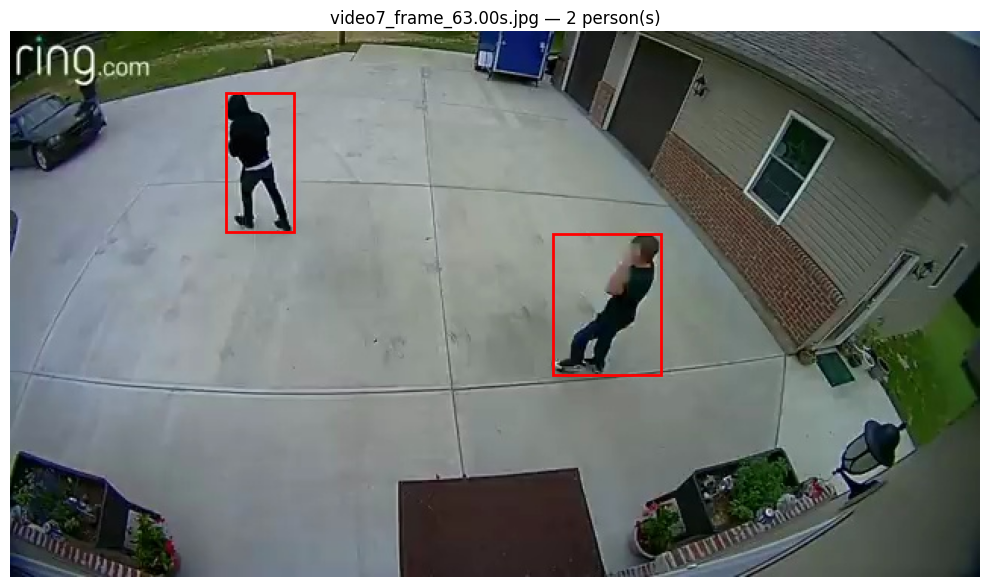

Image size: 640x360
  bbox: [358.0, 133.0, 71.0, 93.0]  area: 6602.96
  bbox: [142.0, 40.0, 45.0, 92.0]  area: 4139.98


In [3]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Load the train annotations
with open(os.path.join(COCO_OUTPUT_DIR, "train", "_annotations.coco.json")) as f:
    coco = json.load(f)

# Pick the first image that has annotations
img_ids_with_anns = set(a["image_id"] for a in coco["annotations"])
sample_img = next(img for img in coco["images"] if img["id"] in img_ids_with_anns)
sample_anns = [a for a in coco["annotations"] if a["image_id"] == sample_img["id"]]

# Load and display
img_path = os.path.join(COCO_OUTPUT_DIR, "train", sample_img["file_name"])
img = Image.open(img_path)

fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(img)

for ann in sample_anns:
    x, y, w, h = ann["bbox"]
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)

ax.set_title(f"{sample_img['file_name']} — {len(sample_anns)} person(s)")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Image size: {sample_img['width']}x{sample_img['height']}")
for ann in sample_anns:
    print(f"  bbox: {ann['bbox']}  area: {ann['area']}")

In [4]:
!pip install albumentations==1.4.21

---
## Step 3: Train RF-DETR Nano

**Notes:**
- Resolution must be divisible by 56. Closest to your 832 is **840**.
- `batch_size * grad_accum_steps` should equal ~16 for fair comparison.
- RF-DETR Nano has 30.5M params (vs ~2.6M for YOLO11n) — it's heavier.

In [5]:
from rfdetr import RFDETRNano

model = RFDETRNano()

model.train(
    dataset_dir=COCO_OUTPUT_DIR,
    epochs=40,
    batch_size=4,
    grad_accum_steps=4,       # effective batch size = 16 (matches YOLO experiments)
    lr=2e-4,
    resolution=896,           # must be divisible by 56, closest to 832
    output_dir="/workspace/FYP_RESULTS/Final-Year-Project/runs/rfdetr/rfdetr_nano_real_e40",
)

[2026-03-20 22:31:45] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-03-20 22:31:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-20 22:31:45] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-20 22:31:46] [INFO] rf-detr - Loading pretrain weights


[2026-03-20 22:31:50] [WARNING] rf-detr - Reinitializing your detection head with 1 classes.


[2026-03-20 22:31:50] [INFO] rf-detr - TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir /workspace/FYP_RESULTS/Final-Year-Project/runs/rfdetr/rfdetr_nano_real_e40' and open http://localhost:6006/ in browser.
[2026-03-20 22:31:50] [INFO] rf-detr - Not using distributed mode
[2026-03-20 22:31:50] [INFO] rf-detr - git:
  unknown

[2026-03-20 22:31:50] [INFO] rf-detr - Namespace(num_classes=1, grad_accum_steps=4, print_freq=10, amp=True, lr=0.0002, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=40, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', ou

fatal: not a git repository (or any of the parent directories): .git


[2026-03-20 22:31:59] [INFO] rf-detr - Epoch: [1/40]  [  0/112]  eta: 0:15:19  lr: 0.000200  class_error: 0.00  loss: 9.9939 (9.9939)  loss_ce: 0.8525 (0.8525)  loss_bbox: 1.1731 (1.1731)  loss_giou: 0.8857 (0.8857)  loss_ce_0: 0.7418 (0.7418)  loss_bbox_0: 1.4508 (1.4508)  loss_giou_0: 1.0230 (1.0230)  loss_ce_enc: 0.7038 (0.7038)  loss_bbox_enc: 1.7671 (1.7671)  loss_giou_enc: 1.3961 (1.3961)  loss_ce_unscaled: 0.8525 (0.8525)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.2346 (0.2346)  loss_giou_unscaled: 0.4428 (0.4428)  cardinality_error_unscaled: 0.5000 (0.5000)  loss_ce_0_unscaled: 0.7418 (0.7418)  loss_bbox_0_unscaled: 0.2902 (0.2902)  loss_giou_0_unscaled: 0.5115 (0.5115)  cardinality_error_0_unscaled: 0.5000 (0.5000)  loss_ce_enc_unscaled: 0.7038 (0.7038)  loss_bbox_enc_unscaled: 0.3534 (0.3534)  loss_giou_enc_unscaled: 0.6980 (0.6980)  cardinality_error_enc_unscaled: 0.5000 (0.5000)  time: 8.2095  data: 2.0065  max mem: 4964
[2026-03-20 22:32:21] [INFO] rf-de

---
## Step 4: Evaluate on Real Test Set

RF-DETR returns `supervision.Detections` objects, so we evaluate using
the COCO test annotations we already created.

In [7]:
import json
import numpy as np
from PIL import Image
from rfdetr import RFDETRNano

import os
COCO_OUTPUT_DIR = "/workspace/FYP_RESULTS/Final-Year-Project/datasets/my_data_coco"   

# Load trained model from best checkpoint
model = RFDETRNano(pretrain_weights="/workspace/FYP_RESULTS/Final-Year-Project/runs/rfdetr/rfdetr_nano_real_e40/checkpoint_best_total.pth")

# Load test annotations
test_dir = os.path.join(COCO_OUTPUT_DIR, "test")
with open(os.path.join(test_dir, "_annotations.coco.json")) as f:
    test_coco = json.load(f)

# Run predictions on all test images
all_predictions = []  # list of dicts for COCO eval
pred_id = 0

for img_info in test_coco["images"]:
    img_path = os.path.join(test_dir, img_info["file_name"])
    image = Image.open(img_path)
    
    # RF-DETR predict returns supervision.Detections
    detections = model.predict(image, threshold=0.25)
    
    # Convert to COCO prediction format
    if detections and len(detections.xyxy) > 0:
        for i in range(len(detections.xyxy)):
            x1, y1, x2, y2 = detections.xyxy[i]
            score = float(detections.confidence[i])
            cat_id = int(detections.class_id[i])
            
            all_predictions.append({
                "id": pred_id,
                "image_id": img_info["id"],
                "category_id": cat_id,
                "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                "score": score
            })
            pred_id += 1

print(f"Total predictions: {len(all_predictions)} across {len(test_coco['images'])} test images")

[2026-03-21 05:25:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-21 05:25:45] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-21 05:25:45] [INFO] rf-detr - Loading pretrain weights


[2026-03-21 05:25:45] [WARNING] rf-detr - Reinitializing detection head with 0 classes based on pretrained weights, configured for 90.
[2026-03-21 05:25:45] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Total predictions: 800 across 660 test images


In [8]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Run official COCO evaluation
coco_gt = COCO(os.path.join(test_dir, "_annotations.coco.json"))
coco_dt = coco_gt.loadRes(all_predictions)

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# Extract key metrics
# stats[0] = mAP@0.50:0.95
# stats[1] = mAP@0.50
print(f"\n===== RF-DETR Nano FINAL TEST METRICS =====")
print(f"mAP@0.50:        {coco_eval.stats[1]:.4f}")
print(f"mAP@0.50:0.95:   {coco_eval.stats[0]:.4f}")
print("============================================\n")
print("Note: For precision/recall comparable to Ultralytics output,")
print("see the COCOeval summary above (AR = recall at various settings).")

# ============================================================
# Comparison table — fill in after running all models
# ============================================================

results = {
    "YOLO11n (Exp 1)": {"mAP50": 0.931, "mAP50-95": 0.735, "Precision": 0.949, "Recall": 0.892},
    "YOLOv10n":        {"mAP50": 0.935, "mAP50-95": 0.702, "Precision": 0.960, "Recall": 0.859},
    "YOLO v26n":       {"mAP50": 0.924, "mAP50-95": 0.745, "Precision": 0.931, "Recall": 0.884},
    "RF-DETR-N":       {"mAP50": 0.916, "mAP50-95": 0.724, "Precision": None,  "Recall": 0.770},
}

print(f"\n{'Model':<20} {'mAP@50':>8} {'mAP@50-95':>10} {'Precision':>10} {'Recall':>8}")
print("-" * 60)
for name, m in results.items():
    vals = [f"{v:.3f}" if v is not None else "   -" for v in m.values()]
    print(f"{name:<20} {vals[0]:>8} {vals[1]:>10} {vals[2]:>10} {vals[3]:>8}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.24s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.724
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.916
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.816
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.247
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.772
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.674
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.770
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

---
## Step 5: Export Model (for Experiment 3 — Pi 5 deployment)
Run this after training to save the ONNX for later quantization.

In [ ]:
# Uncomment when ready for Experiment 3
# !pip install rfdetr[onnxexport]
#
# model.export(output_dir="/workspace/Final-Year-Project/runs/rfdetr/rfdetr_nano_real_e40/export")
# print("ONNX model exported.")